In [1]:
import numpy as np
import numpyro
import numpyro.distributions as dist
from tqdm.notebook import tqdm

from modulars.plot_rr import plot_a_few_trajectories_1d, plot_mean_band_rrs_1d
from modulars.utils import load_config, load_best_values, logistic_moments
from modulars.distributions import binomial, beta_posterior
from modulars.utils import _logistic_normal_mean_std_mc, _trace_locscale_to_theta_moments
trace_fn = logistic_moments
transform_fn = logistic_moments
data_gen = binomial

In [2]:
config_file = "../beta_config.json"
config = load_config(config_file)

theta_like = config['theta_like']
alpha_prior = config['alpha_prior']
beta_prior = config['beta_prior']
n_samples = config['n_samples']

data = data_gen(n_samples) if n_samples > 0 else 0

from modulars import print_model_info
print_model_info(
    "Beta", "Binomial", "Beta",
    [alpha_prior, beta_prior], [theta_like],
    data=data, posterior_func=beta_posterior,
    n_samples=n_samples)


Prior: Beta([0.5, 0.6])
Likelihood: Binomial([0.7])
Data: 7
Posterior: Beta({'alpha_post': 7.5, 'beta_post': 3.5999999999999996, 'mean_post': 0.6756756756756757, 'std_post': np.float64(0.13457556695458628)})


In [3]:
# copy-pasted from beta_numpyro.ipynb
# run in numpyro

def model(y):
    theta = numpyro.sample("theta", dist.Beta(alpha_prior, beta_prior))
    numpyro.sample("obs", dist.Binomial(n_samples, theta), obs=y)


In [4]:
from modulars import run_restart_1d
results = []
for seed in tqdm(range(100)):
    result = run_restart_1d(seed, model, data, 'theta', 100_000, n_particles=100)
    print(result)
    results.append(result)


  0%|          | 0/100 [00:00<?, ?it/s]

(Array([0.2232025 , 0.22370295, 0.22420374, ..., 0.8078506 , 0.80803674,
       0.8081123 ], dtype=float32), Array([0.1000476 , 0.10009516, 0.10014272, ..., 0.6697596 , 0.66963094,
       0.6694456 ], dtype=float32), Array([1.9651382 , 1.9646381 , 1.964138  , ..., 0.81307673, 0.813137  ,
       0.8131738 ], dtype=float32), Array([0.1000476 , 0.10009518, 0.10014279, ..., 0.6716332 , 0.67160237,
       0.6715887 ], dtype=float32))
(Array([1.590563  , 1.5900643 , 1.5895665 , ..., 0.78203964, 0.78231406,
       0.782539  ], dtype=float32), Array([0.1000476 , 0.10009527, 0.10014306, ..., 0.6663664 , 0.6662873 ,
       0.6662312 ], dtype=float32), Array([0.19599989, 0.19650033, 0.1970002 , ..., 0.8073452 , 0.8073704 ,
       0.80746037], dtype=float32), Array([0.1000476 , 0.10009516, 0.10014279, ..., 0.6680776 , 0.66807073,
       0.6680684 ], dtype=float32))
(Array([-0.38019726, -0.37970078, -0.37920177, ...,  0.78990734,
        0.7897585 ,  0.7897211 ], dtype=float32), Array([0.1000476 , 

  0%|          | 0/100 [00:00<?, ?it/s]

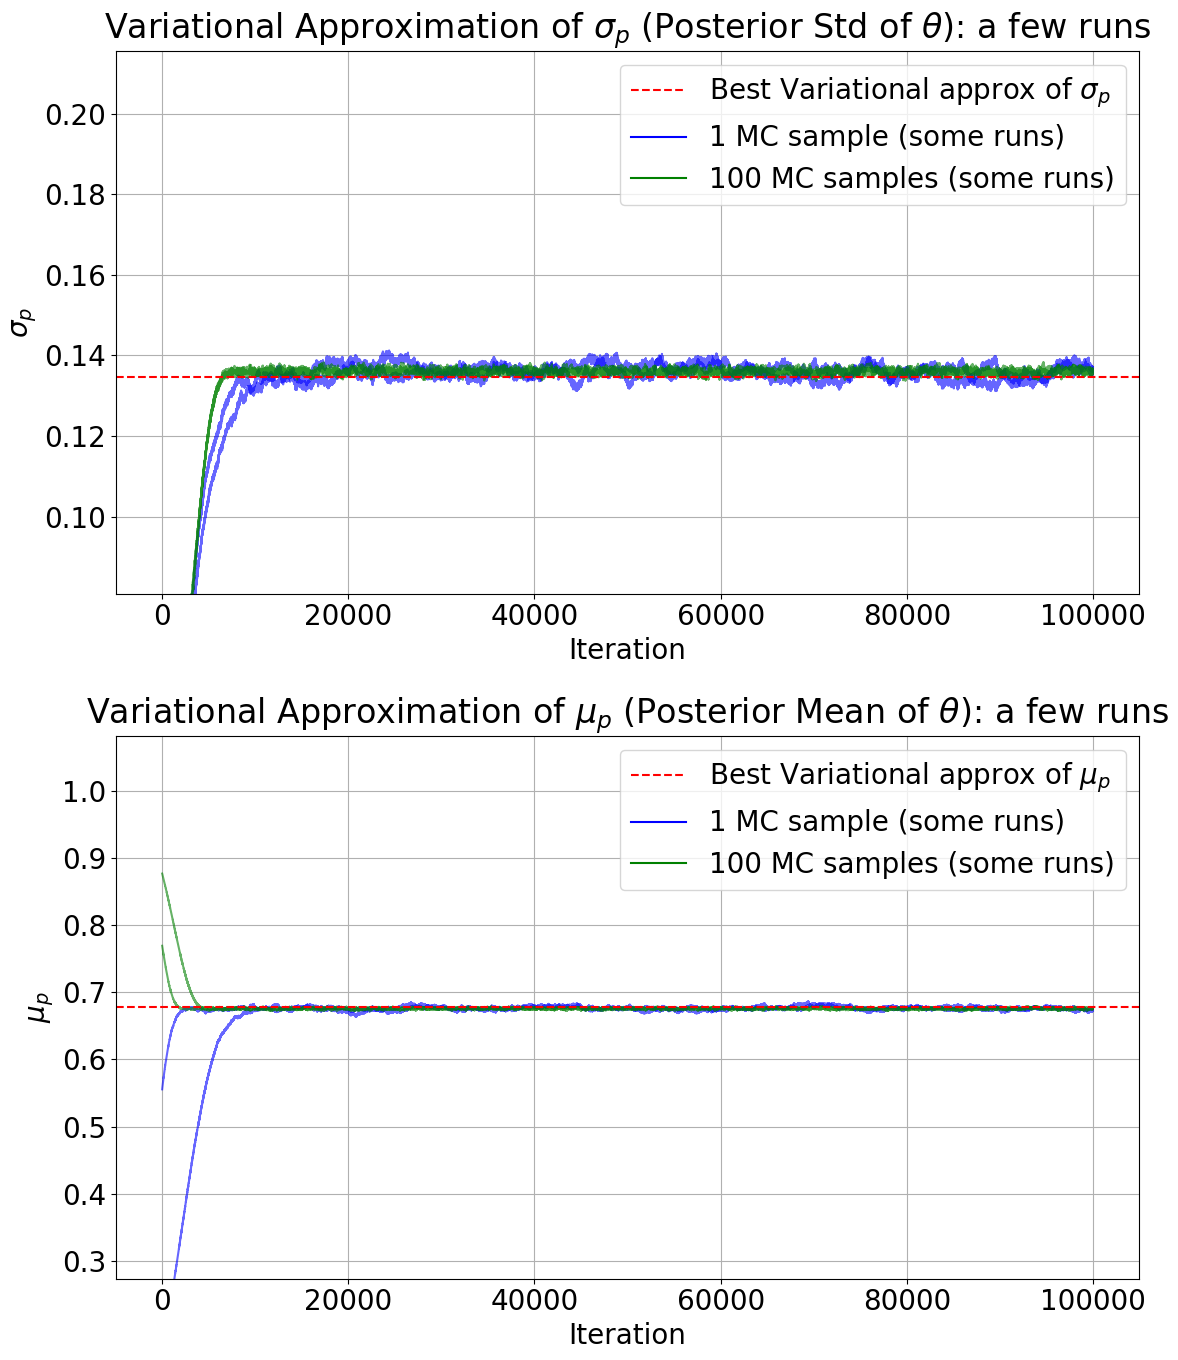

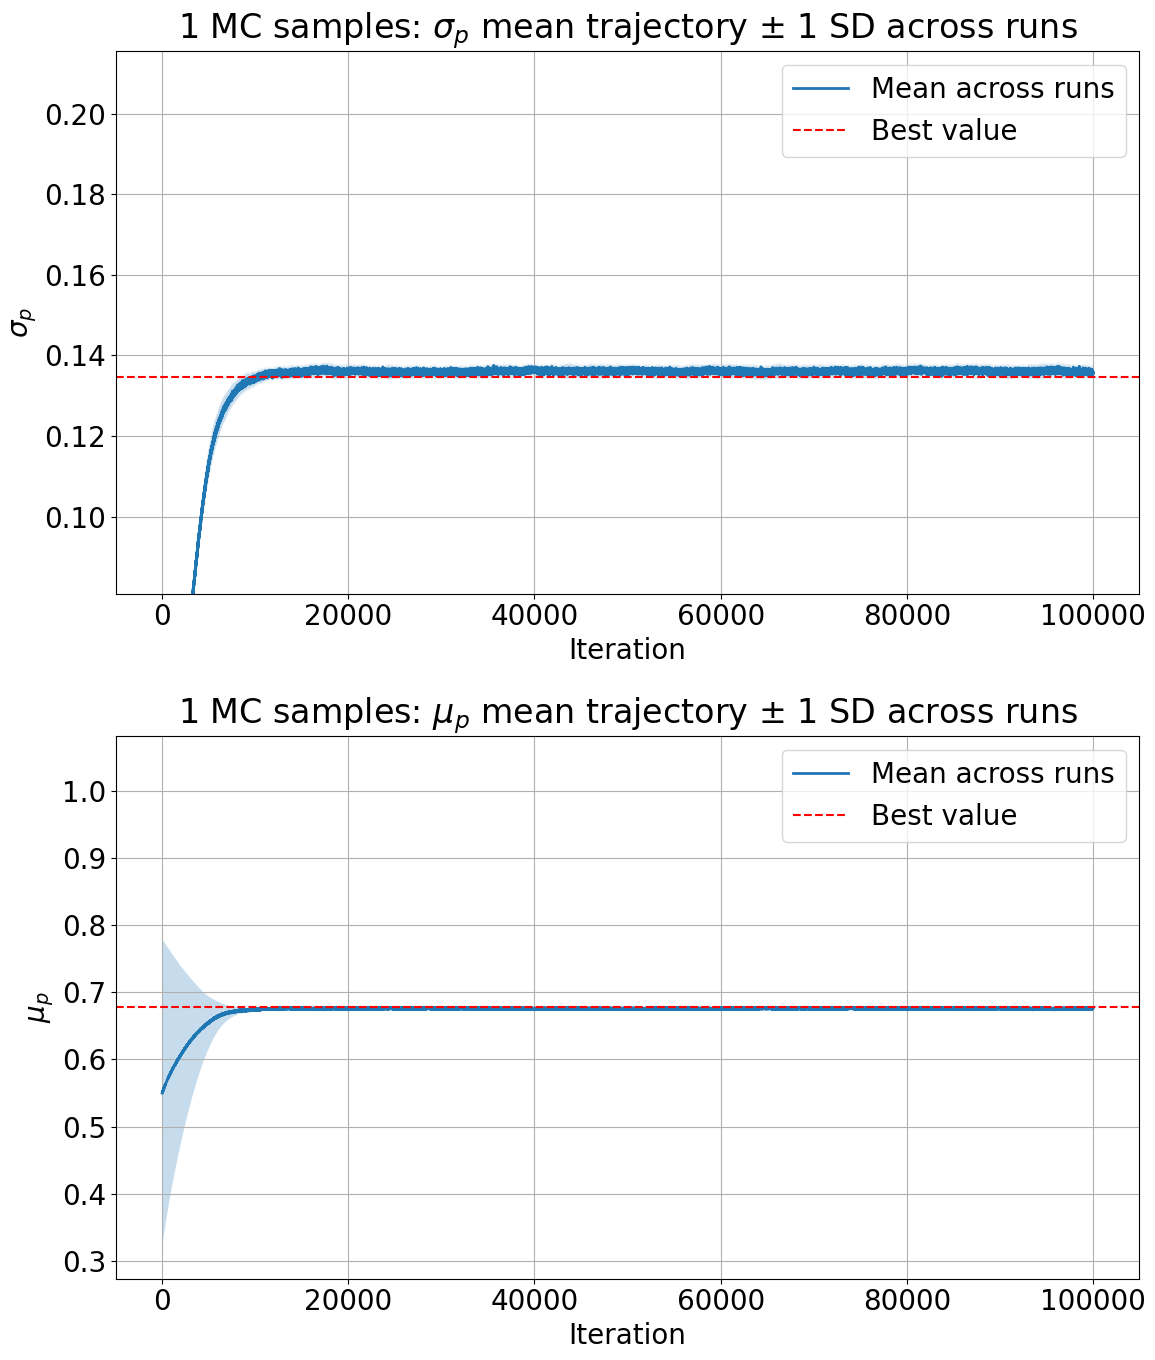

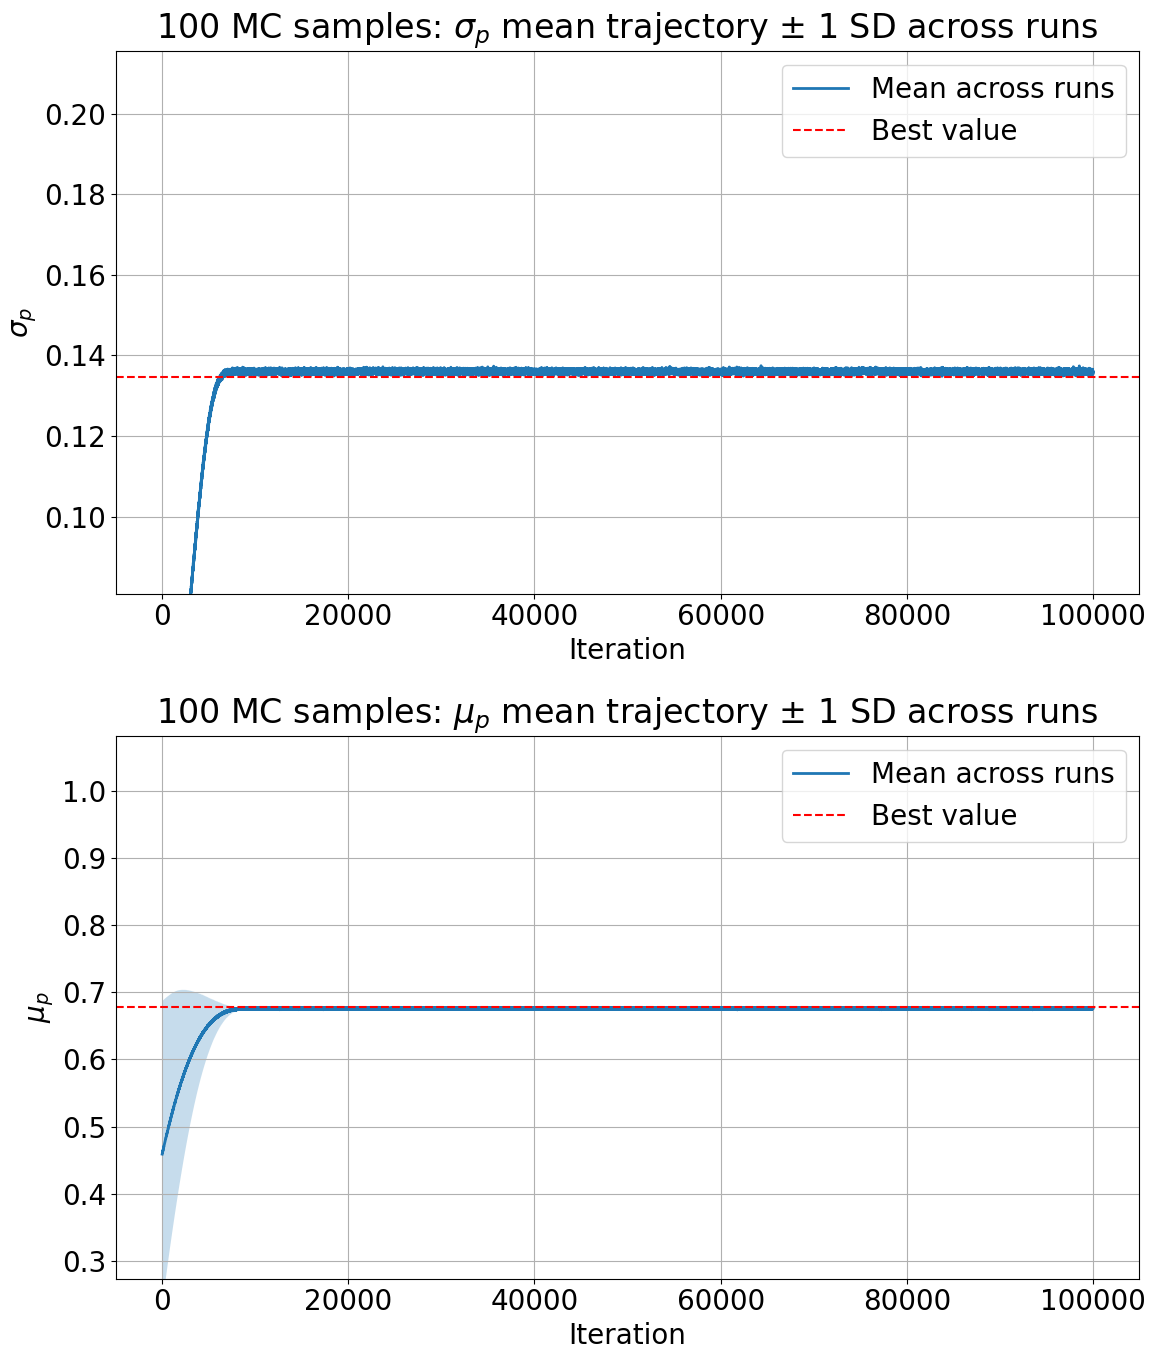

In [7]:
from modulars import apply_traj_transform
single_means, single_stds, multi_means, multi_stds = \
apply_traj_transform(results, transform_fn, n_samples=100_000, seed=1, NOTEBOOK=True)
N, T = single_means.shape
x = np.arange(T)
# If we have "best" from config, these should be on theta-scale (0,1)
best_mu, best_std = load_best_values(
    config=config, transform=trace_fn,
    n_samples=50_000, seed=1)

plot_a_few_trajectories_1d(
    [single_means, single_stds], [multi_means, multi_stds],
    best_mu, best_std, r'$\theta$')
plot_mean_band_rrs_1d(
    single_means, single_stds, best_mu, best_std,
    x, r'$\theta$', 1)
plot_mean_band_rrs_1d(
    multi_means, multi_stds, best_mu, best_std,
    x, r'$\theta$', 100)

In [6]:
results[0]

(Array([0.2232025 , 0.22370295, 0.22420374, ..., 0.8078506 , 0.80803674,
        0.8081123 ], dtype=float32),
 Array([0.1000476 , 0.10009516, 0.10014272, ..., 0.6697596 , 0.66963094,
        0.6694456 ], dtype=float32),
 Array([1.9651382 , 1.9646381 , 1.964138  , ..., 0.81307673, 0.813137  ,
        0.8131738 ], dtype=float32),
 Array([0.1000476 , 0.10009518, 0.10014279, ..., 0.6716332 , 0.67160237,
        0.6715887 ], dtype=float32))